# Hierarchical Agent란?

**Hierarchical Agent**는 계층적 구조로 작업을 **분류하고 위임**하는 Multi-Agent 패턴입니다.



### 핵심 특징

1. **단순 분류와 실행** (Classify & Execute)
   - 상위 에이전트가 입력을 분석하여 적절한 하위 에이전트로 라우팅
   - 한 번의 분류로 작업 완료 (1회성 실행)
   
2. **명확한 역할 분담** (Clear Role Division)
   - 각 하위 에이전트는 특정 도메인에 특화
   - 서로 독립적으로 작동
   
3. **조건부 라우팅** (Conditional Routing)
   - 입력 내용에 따라 다른 경로로 분기
   - if-else 로직과 유사한 흐름

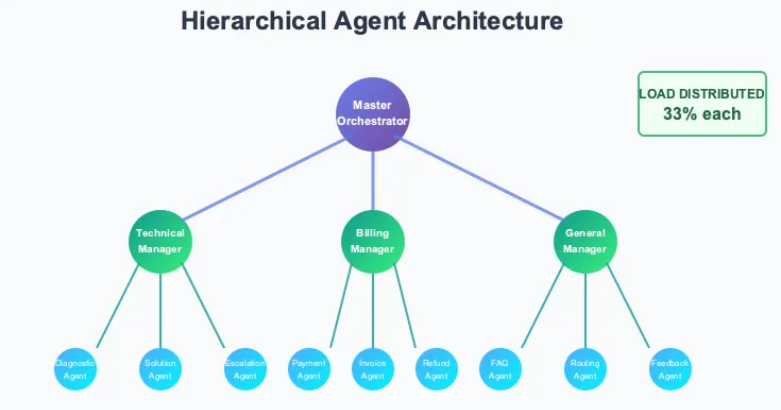

# Multi Agents - 고객 지원 챗봇
LangGraph를 활용하여 여러 에이전트가 협력하는 고객 지원 챗봇을 구현합니다.


### 작동 방식

```
사용자 입력
    ↓
분류 에이전트 (Classifier)
    ↓
조건부 라우팅
    ├─→ 에이전트 A (특정 업무)
    ├─→ 에이전트 B (특정 업무)
    └─→ 에이전트 C (특정 업무)
    ↓
최종 응답
```


### 적합한 사용 사례

- 고객 지원 시스템 (기술/결제/일반 상담)
- 문서 분류 및 처리
- 이메일 자동 라우팅
- 간단한 의사결정 트리


## 구성
1. **분류 에이전트**: 고객 문의 유형을 판단 (기술/결제/일반)
2. **기술 지원 에이전트**: 기술 문제 해결
3. **결제 지원 에이전트**: 결제 관련 처리
4. **일반 상담 에이전트**: 일반 문의 응답


### 이 예제가 Hierarchical Agent인 이유

**고객 지원 챗봇**은 Hierarchical Agent의 전형적인 사례입니다:

1. **분류 단계**: 고객 문의를 분석하여 유형 판단 (기술/결제/일반)
2. **라우팅**: 문의 유형에 따라 전문 에이전트로 분기
3. **독립 실행**: 각 지원 에이전트가 자신의 영역만 처리
4. **1회성 완료**: 한 번의 라우팅으로 작업 종료

**vs. Supervisor Agent**: Supervisor는 여러 에이전트를 순차적으로 조율하지만, Hierarchical은 단순히 하나의 에이전트를 선택하여 실행합니다.

## 학습 목표
- 조건부 라우팅 (conditional routing)
- 상태 관리 (state management)
- 여러 에이전트 중 선택적 실행

## 1단계: LLM 모델 초기화 


In [1]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    keep_alive="5m"
)

## 2단계: 상태 정의 (State Management)

그래프에서 사용할 상태 구조를 정의합니다. 상태는 모든 노드 간에 공유되며, 각 에이전트가 정보를 추가하거나 수정할 수 있습니다.


In [3]:
from typing import TypedDict, NotRequired, Literal

class SupportState(TypedDict):
    """
    고객 지원 챗봇의 상태를 표현하는 타입.

    Attributes:
        question (str): 고객이 입력한 원본 문의 내용.
        category (Literal["technical", "billing", "general"] | None):
            분류 에이전트가 판별한 문의 유형.
            초기 상태에서는 None일 수 있음.
        response (NotRequired[str]):
            최종 지원 에이전트가 생성한 응답 메시지.
            아직 생성되지 않은 경우 omitted(없음)이 될 수 있음.
    """

    question: str
    category: Literal["technical", "billing", "general"] | None
    response: NotRequired[str]
    


## 3단계: 에이전트 노드 정의

각 에이전트의 역할과 기능을 정의합니다.


### 분류 에이전트 (Classifier Agent)

고객의 문의 내용을 분석하여 적절한 지원 유형으로 분류합니다.


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def classifier_agent(state: SupportState) -> SupportState:
    """
    고객 문의를 분석하여 적절한 카테고리로 분류하는 에이전트
    """
    question = state["question"]
    
    # LLM을 사용하여 문의 유형 분류
    messages = [
        SystemMessage(content="""
            당신은 고객 문의를 분류하는 전문가입니다.
            고객의 문의를 다음 세 가지 카테고리 중 하나로 분류하세요:

            1. technical - 기술적 문제, 오류, 버그, 기능 작동 문제 등
            2. billing - 결제, 환불, 요금제, 구독 관련 문제
            3. general - 일반 문의, 제품 정보, 사용 방법 등

            반드시 'technical', 'billing', 'general' 중 하나의 단어만 응답하세요."""),
        HumanMessage(content=f"다음 문의를 분류하세요: {question}")
    ]
    
    response = llm.invoke(messages)
    category = response.content.strip().lower()
    
    print(f"[분류 에이전트] 문의 유형: {category}")
    
    return {
        "question": question,
        "category": category
    }


In [5]:
# 테스트
test_state = {"question": "로그인이 안됩니다"}
result = classifier_agent(test_state)
print(f"분류 결과: {result['category']}")

[분류 에이전트] 문의 유형: technical
분류 결과: technical


### 기술 지원 에이전트

기술적인 문제를 해결하는 전문 에이전트입니다.


In [6]:
def technical_support_agent(state: SupportState) -> SupportState:
    """
    기술적 문제를 해결하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 기술 지원 전문가입니다.
            고객의 기술적 문제를 친절하고 명확하게 해결해주세요.
            단계별 해결 방법을 제시하고, 가능한 원인을 설명하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[기술 지원 에이전트] 응답 생성 완료")
    
    return {
        "question": question,
        "category": state["category"],
        "response": answer
    }


### 결제 지원 에이전트

결제 및 청구 관련 문제를 처리하는 에이전트입니다.


In [7]:
def billing_support_agent(state: SupportState) -> SupportState:
    """
    결제 및 청구 관련 문제를 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 결제 및 청구 관련 전문 상담원입니다.
            고객의 결제, 환불, 요금제 관련 문의에 정확하고 친절하게 답변하세요.
            필요한 경우 정책과 절차를 안내하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[결제 지원 에이전트] 응답 생성 완료")
    
    return {
        "question": question,
        "category": state["category"],
        "response": answer
    }


### 일반 상담 에이전트

일반적인 문의사항을 처리하는 에이전트입니다.


In [8]:
def general_support_agent(state: SupportState) -> SupportState:
    """
    일반적인 문의사항을 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 친절한 고객 상담원입니다.
            고객의 일반적인 문의에 친절하고 유용한 정보를 제공하세요.
            제품이나 서비스에 대한 설명을 명확하게 전달하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[일반 상담 에이전트] 응답 생성 완료")
    
    return {
        "question": question,
        "category": state["category"],
        "response": answer
    }


## 4단계: 조건부 라우팅 (Conditional Routing)

분류 결과에 따라 적절한 에이전트로 라우팅하는 함수를 정의합니다.


In [9]:
from typing import Literal

def route_question(state: SupportState) -> Literal["technical", "billing", "general"]:
    """
    분류된 카테고리에 따라 적절한 에이전트로 라우팅하는 함수
    """
    category = state["category"]
    
    print(f"[라우터] '{category}' 카테고리로 라우팅")
    
    # 카테고리에 따라 다음 노드 결정
    if category == "technical":
        return "technical"
    elif category == "billing":
        return "billing"
    else:
        return "general"


## 5단계: 그래프 구성

LangGraph를 사용하여 전체 워크플로우를 구성합니다.

In [10]:
from langgraph.graph import StateGraph, END, START

# StateGraph 생성
workflow = StateGraph(SupportState)

# 노드 추가
workflow.add_node("classifier", classifier_agent)
workflow.add_node("technical", technical_support_agent)
workflow.add_node("billing", billing_support_agent)
workflow.add_node("general", general_support_agent)

# 시작점 설정
workflow.add_edge(START, "classifier")

# 조건부 엣지 추가 (분류 에이전트 -> 라우팅)
workflow.add_conditional_edges(
    "classifier",  # 출발 노드
    route_question,  # 라우팅 함수
    {
        "technical": "technical",  # 기술 지원으로
        "billing": "billing",      # 결제 지원으로
        "general": "general"       # 일반 상담으로
    }
)

# 각 전문 에이전트에서 END로 연결
workflow.add_edge("technical", END)
workflow.add_edge("billing", END)
workflow.add_edge("general", END)

# 그래프 컴파일
app = workflow.compile()


## 6단계: 그래프 시각화 (선택사항)

그래프의 구조를 시각적으로 확인할 수 있습니다.


```
시작
  |
  v
분류 에이전트
  |
  v
조건부 라우팅
  |
  +-- technical --> 기술 지원 에이전트 --> 종료
  |
  +-- billing --> 결제 지원 에이전트 --> 종료
  |
  +-- general --> 일반 상담 에이전트 --> 종료
```


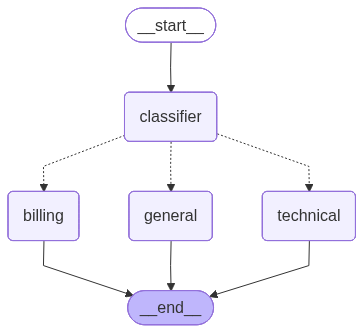

In [11]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7단계: 테스트 예제

다양한 문의 유형으로 챗봇을 테스트해봅니다.


### 테스트 케이스 1: 기술 지원 문의


In [12]:
question1 = "앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?"

# 초기 상태 생성
initial_state = {
    "question": question1
}

# 그래프 실행
result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: technical
[라우터] 'technical' 카테고리로 라우팅
[기술 지원 에이전트] 응답 생성 완료

질문: 앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?
분류: technical

응답:
안녕하세요! 앱이 계속해서 강제 종료되는 문제로 불편을 겪고 계시다니 정말 안타깝습니다. 하지만 걱정 마세요. 제가 단계별로 해결 방법을 안내해 드리겠습니다. 문제 해결을 위해 몇 가지 단계를 밟아보겠습니다.

**1단계: 문제 재현 확인 및 정보 수집**

*   **어떤 앱에서 발생하나요?** 특정 앱에서만 발생하는 문제인지, 아니면 여러 앱에서 모두 발생하는 문제인지 확인해주세요.
*   **언제 강제 종료되나요?** 앱을 실행했을 때 바로 강제 종료되는지, 특정 동작(예: 사진 촬영, 동영상 재생, 게임 플레이)을 할 때만 강제 종료되는지 확인해주세요.
*   **강제 종료되기 전에 어떤 화면이 표시되나요?** 오류 메시지나 경고 메시지가 표시되는지 확인해주세요.
*   **최근에 앱을 업데이트했거나, 새로운 앱을 설치했거나, 시스템 업데이트를 진행했나요?** 최근 변경 사항이 문제의 원인일 수 있습니다.

**2단계: 간단한 해결 방법 시도**

*   **휴대폰 재부팅:** 가장 간단하면서도 효과적인 해결 방법 중 하나입니다. 일시적인 오류를 해결하는 데 도움이 될 수 있습니다.
*   **앱 캐시 및 데이터 삭제:** 앱의 캐시 데이터는 시간이 지나면서 손상되어 문제를 일으킬 수 있습니다. 앱 설정에서 캐시를 삭제해 보세요. (단, 데이터 삭제 시 앱 설정, 로그인 정보 등이 초기화될 수 있습니다.)
*   **앱 업데이트 확인:** 앱 스토어에서 해당 앱의 최신 버전이 있는지 확인하고 업데이트를 진행해주세요. 개발자가 버그를 수정했을 수 있습니다.
*   **시스템 업데이트 확인:** 휴대폰 운영체제(Android 또는 iOS)의 최신 버전이 설치되어 있는지 확인하고 업데이트를 진행해주세요.

**3단계: 심층적인 문제

#### [Langsmith](https://smith.langchain.com/)

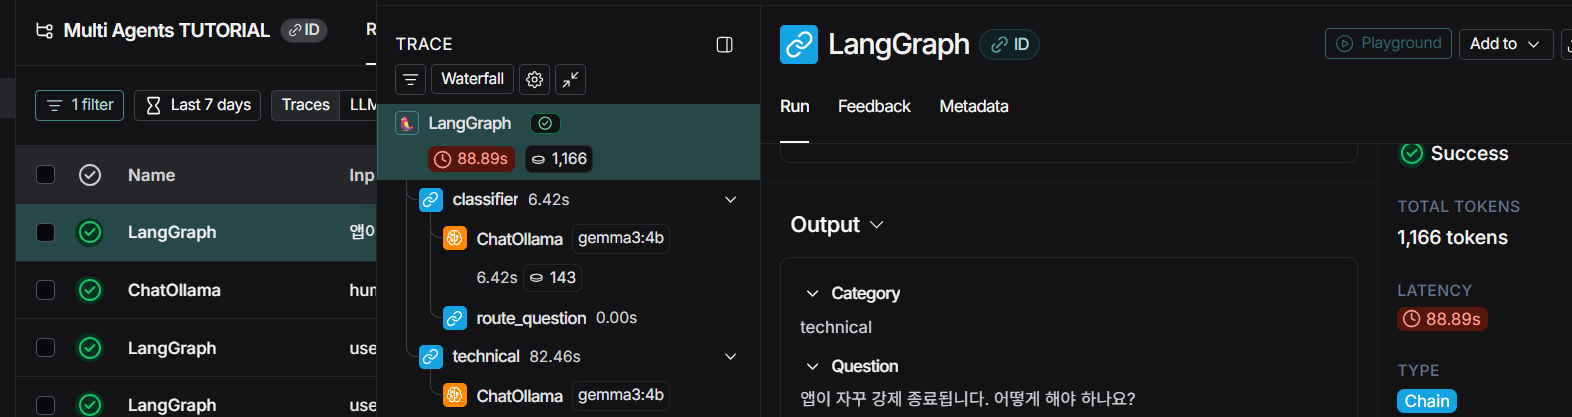

### 테스트 케이스 2: 결제 지원 문의


In [13]:
question2 = "구독을 취소하고 환불받고 싶습니다."

initial_state = {
    "question": question2
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: billing
[라우터] 'billing' 카테고리로 라우팅
[결제 지원 에이전트] 응답 생성 완료

질문: 구독을 취소하고 환불받고 싶습니다.
분류: billing

응답:
안녕하세요. 고객님, 구독 취소 및 환불 문의 주셔서 감사합니다. 불편을 드려 죄송합니다. 

고객님의 상황을 정확히 파악하고 도움을 드리기 위해 몇 가지 질문을 드려도 될까요?

1.  **어떤 서비스에 대한 구독을 취소하고 싶으신가요?** (예: 월간 멤버십, 연간 구독 등)
2.  **구독 계정 정보 (이메일 주소 또는 사용자 이름)를 알려주실 수 있나요?** 계정 정보를 확인하여 정확한 정보를 확인하고 처리하는 데 필요합니다.
3.  **구독 취소 이유를 말씀해주실 수 있나요?** (예: 서비스 이용 중단, 가격 문제 등)
4.  **환불을 받으려는 기간은 언제부터인가요?** (예: 현재 사용 중인 기간, 다음 달부터 등)

**일반적인 구독 취소 및 환불 정책은 다음과 같습니다.**

*   **취소 절차:** 대부분의 구독 서비스는 계정 설정 페이지 또는 고객센터를 통해 구독을 취소할 수 있습니다.
*   **환불 정책:** 환불 가능 여부는 서비스 제공업체마다 다르며, 일반적으로 다음과 같은 기준으로 결정됩니다.
    *   **취소 시점:** 구독 시작 후 일정 기간이 지난 경우 환불이 가능할 수 있습니다. (예: 월간 구독의 24시간 이내, 1주일 이내 등)
    *   **사용 기간:** 서비스 이용 기간 동안 사용하지 않은 경우 환불이 가능할 수 있습니다.
    *   **정책:** 서비스 제공업체의 환불 정책을 확인하여 환불 조건 및 절차를 확인해주세요.

**환불 절차는 일반적으로 다음과 같습니다.**

1.  **환불 신청:** 고객센터에 환불 신청을 하거나, 온라인 환불 신청 페이지를 통해 신청합니다.
2.  **환불 승인:** 서비스 제공업체는 환불 신청 내용을 검토하고, 환불 승인 여부를 결정합니다.
3.  **환불 처리:

### 테스트 케이스 3: 일반 상담 문의


In [14]:
question3 = "프리미엄 플랜에는 어떤 기능들이 포함되나요?"

initial_state = {
    "question": question3
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: general
[라우터] 'general' 카테고리로 라우팅
[일반 상담 에이전트] 응답 생성 완료

질문: 프리미엄 플랜에는 어떤 기능들이 포함되나요?
분류: general

응답:
안녕하세요! 프리미엄 플랜에 대해 문의주셔서 감사합니다. 프리미엄 플랜은 저희 서비스를 최대한 활용하실 수 있도록 설계된 가장 강력한 플랜입니다. 주요 기능은 다음과 같습니다.

**1. 무제한 사용:**

*   저장 공간: 무제한으로 데이터를 저장할 수 있습니다.
*   API 호출: API 호출 횟수에 제한 없이 사용할 수 있어, 개발자분들이나 대량의 데이터를 처리해야 하는 사용자에게 매우 유용합니다.
*   사용자 수: 무제한 사용자 계정을 생성하여 팀원들과 함께 서비스를 이용할 수 있습니다.

**2. 고급 기능:**

*   **실시간 협업:** 실시간으로 다른 사용자들과 함께 작업을 진행하고, 즉각적인 피드백을 주고받을 수 있습니다.
*   **맞춤형 워크플로우:** 사용자의 요구에 맞춰 워크플로우를 설정하고 사용자 정의할 수 있습니다.
*   **우선 지원:** 기술 지원팀에 문의 시, 우선적으로 지원을 받을 수 있습니다. 평균 대기 시간이 단축되어 신속하게 문제를 해결할 수 있습니다.
*   **데이터 분석:** 고급 데이터 분석 기능을 통해 데이터를 심층적으로 분석하고, 비즈니스 인사이트를 얻을 수 있습니다.
*   **자동화:** 반복적인 작업을 자동화하여 생산성을 향상시킬 수 있습니다.

**3. 추가 혜택:**

*   **정기적인 업데이트:** 최신 기능과 개선 사항을 가장 먼저 경험할 수 있습니다.
*   **전문 교육:** 서비스 활용에 대한 전문 교육을 무료로 제공합니다.
*   **컨설팅:** 서비스 활용에 대한 컨설팅을 제공하여, 비즈니스 목표 달성을 지원합니다.

**프리미엄 플랜 가격:** 월 $99, 연간 $999 (연간 구독 시 10% 할인)

더 자세한 정보나 특정 기능에 대한 질문이 있으시면 언제든지 문의